In [7]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ssl._create_default_https_context = ssl._create_stdlib_context

In [8]:
def CentNN(X, n_clusters, epsilon=0.05):
    centroid_X = np.mean(X, axis=0)
    w = [centroid_X + epsilon, centroid_X - epsilon]
    cluster_members = [[], []]
    cluster_indices = []

    for i, x in enumerate(X):
        distances = cdist([x], w, 'euclidean')[0]
        index = np.argmin(distances)
        cluster_indices.append(index)
        w[index] = w[index] + 1 / (1 + len(cluster_members[index])) * (x - w[index])
        cluster_members[index].append(x)

    epoch = 0
    loser = 0
    while True:
        while True:
            loser = 0

            for i in range(len(X)):
                x = X[i]
                distances = cdist([x], w, 'euclidean')[0]
                current_cluster_index = np.argmin(distances)
                previous_cluster_index = cluster_indices[i]

                if previous_cluster_index != current_cluster_index:
                    w[current_cluster_index] = w[current_cluster_index] + (x - w[current_cluster_index]) / (
                                len(cluster_members[current_cluster_index]) + 1)
                    w[previous_cluster_index] = w[previous_cluster_index] - (x - w[previous_cluster_index]) / (
                                len(cluster_members[previous_cluster_index]) - 1)
                    cluster_members[current_cluster_index] = list(cluster_members[current_cluster_index])
                    cluster_members[current_cluster_index].append(x)

                    ind = 0
                    size = len(cluster_members[previous_cluster_index])
                    while ind != size and not np.array_equal(cluster_members[previous_cluster_index][ind], x):
                        ind += 1
                    if ind != size:
                        cluster_members[previous_cluster_index].pop(ind)
                    else:
                        raise ValueError('array not found in list.')

                    cluster_indices[i] = current_cluster_index
                    loser += 1
            if loser == 0:
                break

            epoch += 1

        if len(w) != n_clusters:
            all_error = []
            for i in range(len(w)):
                dists = cdist([w[i]], cluster_members[i], 'euclidean')[0]
                error = np.sum(dists)
                all_error.append(error)

            new_w = w[np.argmax(all_error)] + epsilon
            w.append(new_w)

            cluster_members.append(np.array([]))
        else:
            break

    return np.array(w), cluster_members, epoch

In [9]:
def plot_clusters(clusters, centroids):
    cm = plt.get_cmap('gist_rainbow')
    colors = [cm(1. * i / len(clusters)) for i in range(len(clusters))]
    for i, cluster in enumerate(clusters):
        for point in cluster:
            plt.scatter(point[0], point[1], color=colors[i])

    for centroid in centroids:
        plt.scatter(centroid[0], centroid[1], marker='x', color='black', s=100)
    
    plt.xlabel('X axis')
    plt.ylabel('Y axis')
    plt.show()

Points array shape:  (5000, 2)
Number of epoch:  48


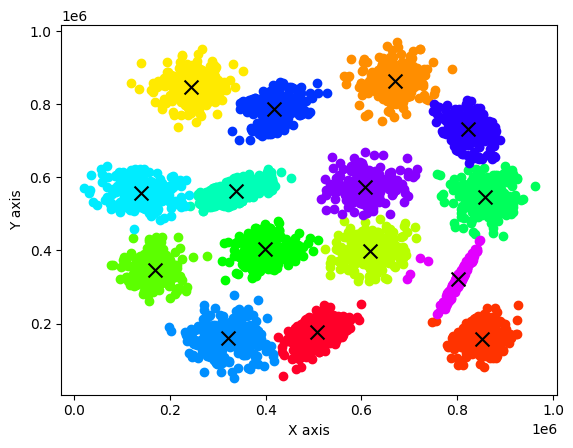

In [10]:
url = "https://web.archive.org/web/20221007090618if_/http://cs.joensuu.fi/sipu/datasets/s1.txt"
response = urllib.request.urlopen(url)
data = response.read().decode('utf-8')

points = []

for line in data.split('\n'):
    if line.strip():
        x, y = map(int, line.strip().split())
        points.append([x, y])

points = np.array(points)
print("Points array shape: ",points.shape)

n_clusters = 15
centroids, clusters, epoch = CentNN(points, n_clusters)
print("Number of epoch: ", epoch)

plot_clusters(clusters, centroids)

Points array shape:  (5000, 2)
Number of epoch:  95


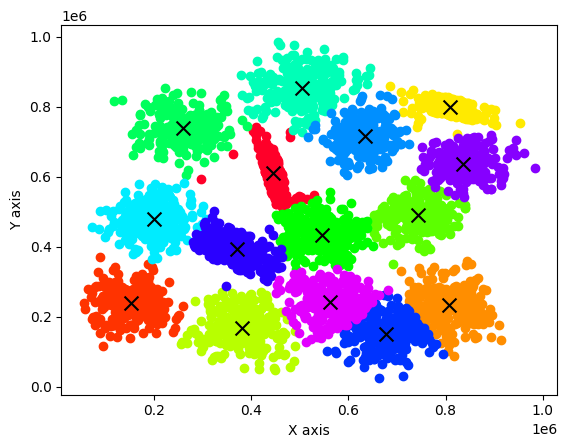

In [11]:
url = "https://web.archive.org/web/20221007091810if_/http://cs.joensuu.fi/sipu/datasets/s2.txt"
response = urllib.request.urlopen(url)
data = response.read().decode('utf-8')

points = []

for line in data.split('\n'):
    if line.strip():
        x, y = map(int, line.strip().split())
        points.append([x, y])

points = np.array(points)
print("Points array shape: ",points.shape)

n_clusters = 15
centroids, clusters, epoch = CentNN(points, n_clusters)
print("Number of epoch: ", epoch)

plot_clusters(clusters, centroids)

Points array shape:  (5250, 2)
Number of epoch:  229


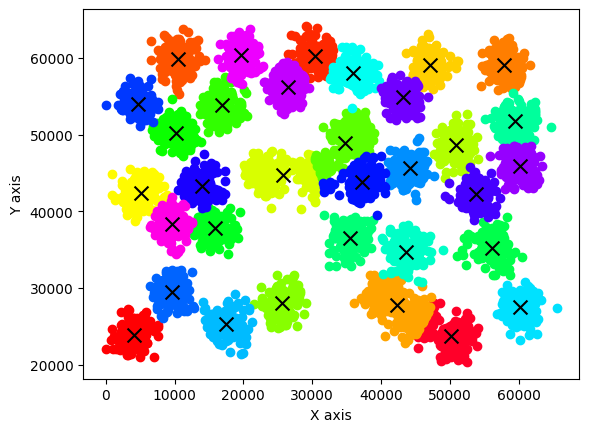

In [12]:
url = "https://web.archive.org/web/20220807160013if_/http://cs.joensuu.fi/sipu/datasets/a2.txt"
response = urllib.request.urlopen(url)
data = response.read().decode('utf-8')

points = []

for line in data.split('\n'):
    if line.strip():
        x, y = map(int, line.strip().split())
        points.append([x, y])

points = np.array(points)
print("Points array shape: ",points.shape)

n_clusters = 33

centroids, clusters, epoch = CentNN(points, n_clusters)
print("Number of epoch: ", epoch)

plot_clusters(clusters, centroids)